# Exercise 3.4: Time to Close Deal. Een betere visual volgens *Storytelling with Data*

**Doel:** de grafiek uit Exercise 3.4 (een geclusterde staafgrafiek van de doorlooptijd van deals bij directe en indirecte verkoop, 2019) omzetten naar een visual die in één oogopslag laat zien of het doel van **90 dagen** gehaald wordt.

We volgen weer de zes lessen uit *Storytelling with Data* (Cole Nussbaumer Knaflic):

| # | Les | Wat het betekent in dit notebook |
|---|-----|----------------------------------|
| 1 | **Begrijp de context** | Wat is de boodschap? Wordt het doel gehaald? |
| 2 | **Kies een passende visual** | Tijdreeks met een doel → lijngrafiek met doellijn |
| 3 | **Verwijder clutter** | Weg met kader, rasterlijnen, legenda |
| 4 | **Stuur de aandacht** | Alleen de maanden boven het doel in kleur |
| 5 | **Denk als een ontwerper** | Directe labels, links uitgelijnde tekst |
| 6 | **Vertel een verhaal** | De titel is de conclusie |

## Stap 0 – Instellingen

**Plan:** libraries laden en kleuren vastleggen. Net als bij de RIVM-opdracht: grijs voor context en **één** accentkleur voor het probleem. Rood betekent hier "doel niet gehaald".

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

BESTAND = "Week_4_EXERCISE_3.xlsx"

GRIJS       = "#BFBFBF"   # context
DONKERGRIJS = "#595959"   # tekst en de 'normale' lijn
ACCENT      = "#C0392B"   # doel niet gehaald

MAANDEN = ["jan", "feb", "mrt", "apr", "mei", "jun",
           "jul", "aug", "sep", "okt", "nov", "dec"]

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Stap 1 – Data inlezen en bekijken

**Plan:** de data staat niet linksboven in het werkblad maar in het blok B5:E17 (met een titel erboven). Daarom geven we `header=4` (rij 5 bevat de kolomnamen), `usecols="B:E"` en `nrows=12` mee.

In [2]:
df = pd.read_excel(BESTAND, header=4, usecols="B:E", nrows=12)
df.columns = ["maand", "Direct", "Indirect", "Doel"]
df["maand"] = pd.to_datetime(df["maand"])
df["mnd"] = MAANDEN                     # korte Nederlandse maandnamen voor de as
DOEL = df["Doel"].iloc[0]               # 90 dagen
df

,maand,Direct,Indirect,Doel,mnd
0,2019-01-01,88.2,82.2,90,jan
1,2019-02-01,76.3,71.4,90,feb
2,2019-03-01,47.8,88.7,90,mrt
3,2019-04-01,76.1,81.0,90,apr
4,2019-05-01,71.4,88.4,90,mei
5,2019-06-01,58.6,120.2,90,jun
6,2019-07-01,79.9,83.5,90,jul
7,2019-08-01,69.4,73.8,90,aug
8,2019-09-01,53.9,98.0,90,sep
9,2019-10-01,80.8,85.1,90,okt


**Wat zien we?** Per maand het gemiddelde aantal **dagen** dat het duurt om een deal te sluiten, voor directe en indirecte verkoop. Het doel is **maximaal 90 dagen**. Bij doorlooptijd is **lager beter**: boven de 90 betekent dat het doel niet gehaald is.

## Stap 2 – Les 1: de context. Wat is het verhaal?

**Plan:** de vraag die een manager hierbij heeft is: *halen we het doel van 90 dagen?* We tellen hoe vaak elk kanaal boven het doel zit en vergelijken de gemiddelden.

In [3]:
samenvatting = pd.DataFrame({
    "gemiddeld (dagen)": df[["Direct", "Indirect"]].mean().round(1),
    "maximum (dagen)": df[["Direct", "Indirect"]].max(),
    "maanden boven doel": (df[["Direct", "Indirect"]] > DOEL).sum(),
})
print(samenvatting, "\n")

boven_doel = df.loc[df["Indirect"] > DOEL, ["mnd", "Indirect"]]
print("Indirect boven het doel:")
print(boven_doel.to_string(index=False))
print("\nIndirect trager dan direct in", (df["Indirect"] > df["Direct"]).sum(), "van 12 maanden")

          gemiddeld (dagen)  maximum (dagen)  maanden boven doel
Direct                 68.6             88.2                   0
Indirect               86.0            120.2                   3 

Indirect boven het doel:
mnd  Indirect
jun     120.2
sep      98.0
nov      94.4

Indirect trager dan direct in 10 van 12 maanden


**Interpretatie:**
- **Direct** haalt het doel **elke maand** (gemiddeld ±69 dagen, maximum 88).
- **Indirect** haalt het doel **3 keer niet**: juni (**120 dagen**), september (98) en november (94).
- Indirect is in **10 van de 12 maanden** trager dan direct (gemiddeld ±86 dagen, dicht tegen de grens aan).

**Onze boodschap ("big idea"):**
> *Directe verkoop haalt het doel van 90 dagen elke maand. Indirecte verkoop zit er 3 keer boven, met een uitschieter van 120 dagen in juni.*

Dat is ook de actie voor de lezer: **zoek uit wat er bij indirecte verkoop in juni, september en november misging.**

## Stap 3 – Waarom niet de originele grafiek? (de "voor"-situatie)

**Plan:** we maken de grafiek na die in het Excel-bestand staat: een geclusterde staafgrafiek met Excel-standaardopmaak.

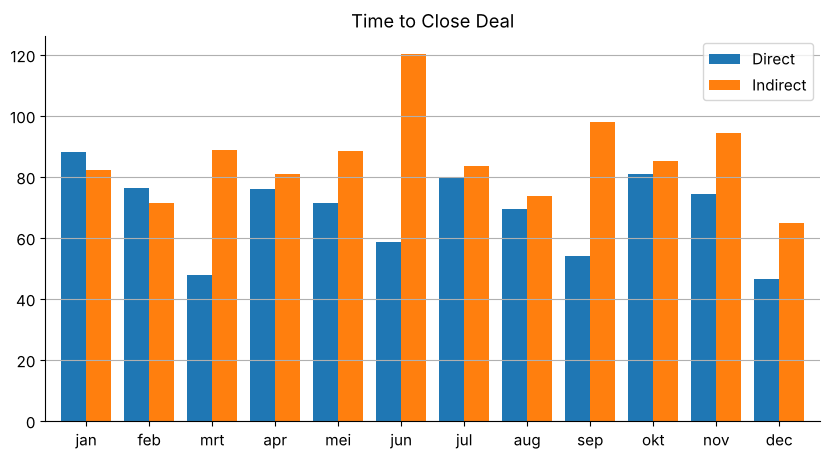

In [4]:
ax = df.set_index("mnd")[["Direct", "Indirect"]].plot(kind="bar", figsize=(10, 5), width=0.8)
ax.set_title("Time to Close Deal")
ax.set_xlabel("")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.show()

**Wat gaat er mis (volgens SWD)?**
- **Het doel staat niet in de grafiek.** Het staat alleen als tekst eronder ("Goal = 90 days"), dus de lezer moet zelf schatten welke staven boven de 90 uitkomen.
- **24 staven naast elkaar**: lastig om een trend over de maanden te volgen.
- **Twee felle kleuren + legenda**: alles schreeuwt even hard om aandacht, en je moet heen en weer kijken naar de legenda.
- **Rasterlijnen en kader**: extra lijnen die niets toevoegen.
- **De titel beschrijft alleen het onderwerp**, niet de conclusie.

## Stap 4 – Les 2: kies de juiste visual → lijngrafiek met doellijn

**Plan:** de x-as is tijd (maanden), dus een **lijngrafiek**. En omdat de vraag "halen we het doel?" is, moet het doel **in** de grafiek staan, als horizontale referentielijn. Eerst een kale versie:

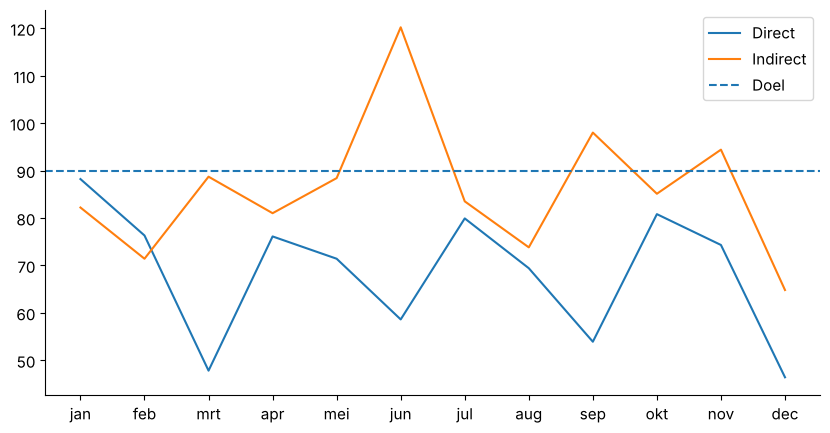

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["mnd"], df["Direct"], label="Direct")
ax.plot(df["mnd"], df["Indirect"], label="Indirect")
ax.axhline(DOEL, linestyle="--", label="Doel")
ax.legend()
plt.show()

**Interpretatie:** met de doellijn erbij zie je direct dat alleen de indirecte lijn erboven uitkomt. Maar er is nog veel clutter (legenda, standaardkleuren) en het oog wordt nog niet naar de probleemmaanden gestuurd.

## Stap 5 – Les 3 t/m 6: de uiteindelijke visual

**Plan:** alle overige lessen tegelijk toepassen:

- **Les 3, clutter weg:** geen kader, geen rasterlijnen, geen legenda.
- **Les 4, aandacht sturen:** direct = grijs (gaat goed, geen actie nodig). Indirect = donkergrijs. **Alleen de 3 maanden boven het doel worden rood**, met hun waarde erbij. Het gebied boven de doellijn krijgt een lichte tint: "hier wil je niet zitten".
- **Les 5, ontwerp:** labels direct aan het eind van de lijnen, ook de doellijn krijgt een eigen label.
- **Les 6, verhaal:** de titel is de conclusie, de ondertitel geeft de onderbouwing.

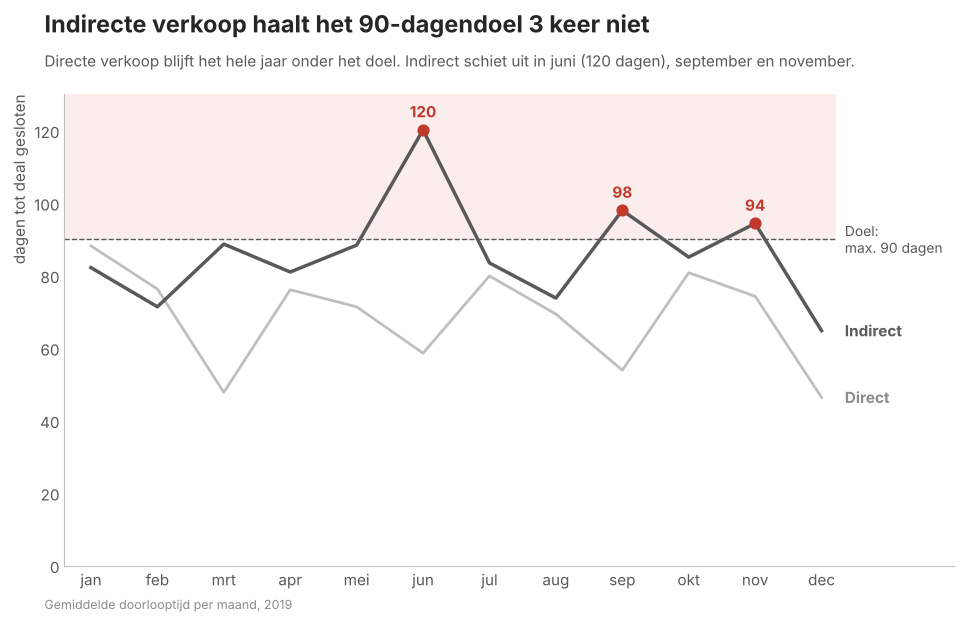

In [6]:
fig, ax = plt.subplots(figsize=(10, 6.2))
x = range(len(df))

# les 4: zone boven het doel licht kleuren
ax.fill_between([-0.4, 11.2], DOEL, 130, color="#FBEDEC", zorder=0)

# doellijn met eigen label (les 5: geen legenda nodig)
ax.hlines(DOEL, -0.4, 11.2, color=DONKERGRIJS, linestyle="--", linewidth=1)
ax.text(11.35, DOEL, f"Doel:\nmax. {DOEL} dagen", color=DONKERGRIJS, va="center", fontsize=10)

# direct = context (gaat goed) -> lichtgrijs
ax.plot(x, df["Direct"], color=GRIJS, linewidth=2)
ax.text(11.35, df["Direct"].iloc[-1], "Direct", color="#8C8C8C", va="center", fontweight="bold")

# indirect = waar het verhaal over gaat -> donkerder
ax.plot(x, df["Indirect"], color=DONKERGRIJS, linewidth=2.5)
ax.text(11.35, df["Indirect"].iloc[-1], "Indirect", color=DONKERGRIJS, va="center", fontweight="bold")

# les 4: alleen de maanden boven het doel in rood, met waarde
for i, rij in df[df["Indirect"] > DOEL].iterrows():
    ax.scatter(i, rij["Indirect"], color=ACCENT, s=60, zorder=4)
    ax.text(i, rij["Indirect"] + 3.5, f"{rij['Indirect']:.0f}",
            color=ACCENT, ha="center", fontweight="bold")

# les 3: clutter weg
ax.set_xticks(list(x), df["mnd"])
ax.set_xlim(-0.4, 13)
ax.set_ylim(0, 130)
ax.set_ylabel("dagen tot deal gesloten", color=DONKERGRIJS, loc="top")
for kant in ("left", "bottom"):
    ax.spines[kant].set_color(GRIJS)
ax.tick_params(colors=DONKERGRIJS, length=0)

# les 6: action title + onderbouwing
fig.text(0.06, 0.95, "Indirecte verkoop haalt het 90-dagendoel 3 keer niet",
         fontsize=17, fontweight="bold", color="#262626")
fig.text(0.06, 0.895,
         "Directe verkoop blijft het hele jaar onder het doel. Indirect schiet uit in juni (120 dagen), "
         "september en november.",
         fontsize=11, color=DONKERGRIJS)
fig.text(0.06, 0.02, "Gemiddelde doorlooptijd per maand, 2019", fontsize=9, color="#8C8C8C")

fig.subplots_adjust(top=0.85, left=0.08, right=0.97, bottom=0.09)
fig.savefig("time_to_close_lijngrafiek.png", dpi=200)
plt.show()

**Interpretatie:** in een paar seconden zie je nu:
1. **wat het doel is**: de stippellijn op 90 dagen,
2. **wie het haalt**: direct blijft er altijd onder (grijs = geen actie nodig),
3. **waar het misgaat**: 3 rode punten bij indirect, met juni als grootste uitschieter (120 dagen).

De lezer hoeft niets meer te schatten of op te zoeken in een legenda.

## Conclusie

| Voor (origineel) | Na (SWD) | Les |
|---|---|---|
| Geclusterde staven, 24 stuks | Lijngrafiek | 2: juiste visual voor tijdreeks |
| Doel alleen als tekst onder de grafiek | Doellijn + gekleurde zone in de grafiek | 1 & 2: de vraag is "halen we het doel?" |
| 2 felle kleuren + legenda | Grijs + rood alleen voor de probleemmaanden, directe labels | 3 & 4: clutter weg, aandacht sturen |
| Titel "Time to Close Deal" | Titel = conclusie | 6: vertel een verhaal |

**Kernboodschap:** directe verkoop haalt het doel van 90 dagen het hele jaar. Indirecte verkoop is bijna elke maand trager en zit 3 keer boven het doel (juni 120, september 98, november 94 dagen). **Aanbevolen actie:** onderzoek wat er in die maanden bij indirecte verkoop is gebeurd.